In [1]:
#Regression

In [2]:
from sklearn.datasets import make_regression

In [3]:
data = make_regression(n_samples=1000, n_features=5, noise=0.2, random_state=42)

In [4]:
X= data[0]

In [5]:
y = data[1]

In [6]:
X[0]

array([ 2.05654356,  0.60685059,  0.48268789, -1.13088844,  0.42009449])

In [7]:
y[0]

np.float64(74.8638525346159)

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()

In [10]:
X = scaler.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [13]:
X_train.shape

(800, 5)

In [14]:
y_train.shape

(800,)

In [15]:
import keras

/Volumes/data/documents/ai_document/.myenv3/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [16]:
model = keras.models.Sequential()
model.add(keras.layers.Input(shape=(5,)))
model.add(keras.layers.Dense(units=16, activation='relu'))
model.add(keras.layers.Dense(units=16, activation='relu'))
model.add(keras.layers.Dense(units=1, activation='linear'))

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
los = keras.losses.MeanSquaredError()
opt = keras.optimizers.Adam()
model.compile(loss=los, optimizer = opt)

In [19]:
model.fit(X_train, y_train, validation_split=0.1, epochs=100, batch_size=50, verbose=2)

Epoch 1/100
15/15 - 0s - 18ms/step - loss: 4039.5356 - val_loss: 4071.3796
Epoch 2/100
15/15 - 0s - 2ms/step - loss: 4023.6958 - val_loss: 4056.1797
Epoch 3/100
15/15 - 0s - 2ms/step - loss: 4005.6746 - val_loss: 4038.8711
Epoch 4/100
15/15 - 0s - 2ms/step - loss: 3984.0615 - val_loss: 4016.8269
Epoch 5/100
15/15 - 0s - 2ms/step - loss: 3954.7969 - val_loss: 3989.4653
Epoch 6/100
15/15 - 0s - 2ms/step - loss: 3919.5930 - val_loss: 3953.4819
Epoch 7/100
15/15 - 0s - 2ms/step - loss: 3873.9143 - val_loss: 3907.4531
Epoch 8/100
15/15 - 0s - 1ms/step - loss: 3818.4949 - val_loss: 3850.5696
Epoch 9/100
15/15 - 0s - 2ms/step - loss: 3748.4785 - val_loss: 3781.6726
Epoch 10/100
15/15 - 0s - 2ms/step - loss: 3665.0693 - val_loss: 3695.7898
Epoch 11/100
15/15 - 0s - 2ms/step - loss: 3565.5129 - val_loss: 3591.9739
Epoch 12/100
15/15 - 0s - 2ms/step - loss: 3444.4104 - val_loss: 3472.0454
Epoch 13/100
15/15 - 0s - 2ms/step - loss: 3307.2769 - val_loss: 3335.0781
Epoch 14/100
15/15 - 0s - 2ms/ste

In [20]:
model.evaluate(X_train, y_train)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - loss: 25.1924


26.46084976196289

In [21]:
model.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 32.6103


33.9408073425293

In [22]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [23]:
y_pred.shape

(200, 1)

In [24]:
y_test.shape

(200,)

In [25]:
import matplotlib.pyplot as plt

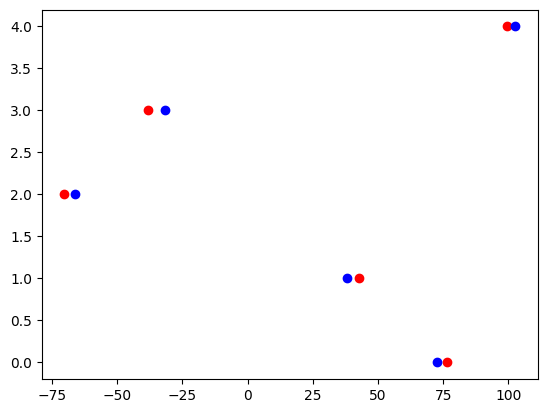

In [26]:
plt.scatter(y_pred[:5], range(5), color='red')
plt.scatter(y_test[:5], range(5), color='blue')
plt.show()